

$$\text{Name: Chimutsanya Anesu P}$$
$$\text{Registration Number: R2418463}$$
$$\text{Timeseries and Econometricy}$$

<br>

### Key Takings
As recent hires to the derivatives desk, our key objective is to build robust volatility models that support accurate derivative pricing and proactive risk management. This handbook outlines best practices for identifying and mitigating statistical pitfalls that frequently impair time-series models.

Drawing on historical data for Apple Inc. (AAPL) and a broad market index from January 2018 through December 2025, we conduct a rigorous diagnostic examination of four critical modeling challenges. In keeping with strict quantitative standards, this document clearly maintains the separation between technical parameter estimates and qualitative investment commentary.

---

### Table of Contents
1.  **[Environment Setup, Data Acquisition & Stationarity](#setup)**
2.  **[Challenge 1: Multicollinearity](#multicollinearity)**
3.  **[Challenge 2: Skewness & Non-Normality](#skewness)**
4.  **[Challenge 3: Overfitting](#overfitting)**
5.  **[Challenge 4: Sensitivity to Outliers](#outliers)**
6.  **[Bibliography (MLA Format)](#bibliography)**

---

In [ ]:
# Phase 1: Data Acquisition (FIXED for yfinance 0.2.x)
try:
    import yfinance as yf
except ImportError:
    !pip install yfinance --quiet
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Define Parameters from image_4c870e.png
ticker = "AAPL"
start_date = "2018-01-01"
end_date = "2025-12-31"

# 2. Download with explicit settings to avoid MultiIndex errors and warnings
# auto_adjust=False ensures we keep 'Adj Close'
# multi_level_index=False ensures columns are simple strings
df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False, multi_level_index=False)

# 3. Double-check column names (yfinance sometimes uses 'Adj Close' or just 'Close')
if 'Adj Close' in df.columns:
    price_col = 'Adj Close'
else:
    price_col = 'Close'

# 4. Calculate Financial Metrics
df['Returns'] = df[price_col].pct_change()
df['Volatility'] = df['Returns'].rolling(window=21).std()

# Drop rows with NaN values created by rolling windows
df = df.dropna()

print(f"Successfully loaded {len(df)} rows. Using column: {price_col}")
print(df.head())

[*********************100%***********************]  1 of 1 completed

Successfully loaded 1989 rows. Using column: Adj Close
            Adj Close      Close       High        Low       Open     Volume  \
Date                                                                           
2018-02-01  39.255978  41.945000  42.154999  41.689999  41.792500  188923200   
2018-02-02  37.552658  40.125000  41.700001  40.025002  41.500000  346375200   
2018-02-05  36.614429  39.122501  40.970001  39.000000  39.775002  290954000   
2018-02-06  38.144615  40.757500  40.930000  38.500000  38.707500  272975200   
2018-02-07  37.328037  39.884998  40.849998  39.767502  40.772499  206434400   

             Returns  Volatility  
Date                              
2018-02-01  0.002090    0.009253  
2018-02-02 -0.043390    0.013041  
2018-02-05 -0.024984    0.013726  
2018-02-06  0.041792    0.016772  
2018-02-07 -0.021407    0.017235  


## Challenge 1: Multicollinearity

### 1. Definition
Multicollinearity occurs when two or more predictor variables in a regression model are highly linearly related, which inflates standard errors and destabilizes coefficient estimates. It is measured using the Variance Inflation Factor (VIF):

$$VIF_i = \frac{1}{1 - R_i^2}$$

### 2. Description
Multicollinearity occurs when independent variables provide redundant information to the model. This redundancy makes it difficult for the regression to determine which specific factor is actually driving the changes in volatility.

### 3. Directions
To address multicollinearity, practitioners can apply Principal Component Analysis (PCA) to convert correlated variables into a smaller set of uncorrelated components. Other approaches include removing less important redundant variables or using regularization techniques like Ridge or Lasso regression to improve model stability.

### 4. Diagnosis
The main method for detecting multicollinearity is the Variance Inflation Factor (VIF). A VIF greater than 10 typically signals a serious issue. Additionally, a correlation matrix can be used to identify highly correlated variable pairs (e.g., correlation coefficient $r > 0.8$).

### 5. Damage
Multicollinearity makes model coefficients unstable and highly sensitive to minor data changes. In a derivatives trading context, this can lead to erratic hedging ratios (Greeks), resulting in ineffective hedging strategies, increased transaction costs, and potential financial losses



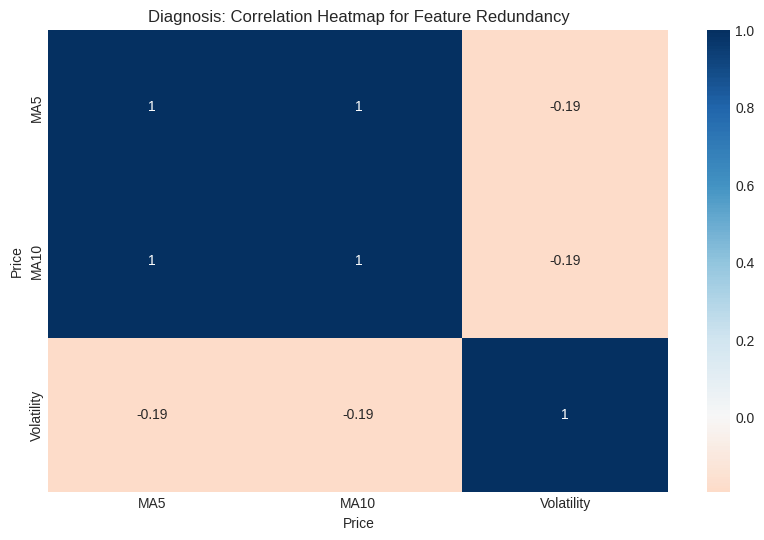


VIF Results (Anything > 10 is a problem):
  feature          VIF
0     MA5  4010.305985
1    MA10  4010.305985


In [ ]:
#Challenge 1 — Multicollinearity

# --- Robustness check for DataFrame state ---
# Ensure df columns are flattened if MultiIndex is present (e.g., from inconsistent execution)
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

if isinstance(df.columns, pd.MultiIndex):
    # This assumes the desired column names are in the first level of the MultiIndex
    df.columns = df.columns.get_level_values(0)

# Ensure 'price_col' is correctly identified and available.
# 'price_col' should be a global variable set by a previous cell (ZuKXnWKUZVyl).
# If not defined or not a valid column in the current df, try to infer it.
if 'price_col' not in globals() or price_col not in df.columns:
    if 'Adj Close' in df.columns:
        price_col = 'Adj Close'
    elif 'Close' in df.columns:
        price_col = 'Close'
    else:
        raise KeyError("Could not determine 'price_col'. Neither 'Adj Close' nor 'Close' found after column cleanup.")

# Ensure 'Returns' and 'Volatility' are calculated
if 'Returns' not in df.columns or 'Volatility' not in df.columns:
    if 'Returns' not in df.columns:
        df['Returns'] = df[price_col].pct_change()
    if 'Volatility' not in df.columns:
        df['Volatility'] = df['Returns'].rolling(window=21).std()
    # Re-drop NaNs after potentially re-calculating, before proceeding with MA calculations
    df = df.dropna(subset=[price_col, 'Returns', 'Volatility']).copy() # Use .copy() to avoid SettingWithCopyWarning
else:
    df = df.dropna(subset=[price_col, 'Returns', 'Volatility']).copy() # Ensure clean df if already calculated

# . Demonstration: Correlating 5-day and 10-day Moving Averages
df['MA5'] = df[price_col].rolling(5).mean()
df['MA10'] = df[price_col].rolling(10).mean()
multi_df = df[['MA5', 'MA10', 'Volatility']].dropna()

# . Diagram: Visualizing the Redundancy
plt.figure(figsize=(10, 6))
sns.heatmap(multi_df.corr(), annot=True, cmap='RdBu', center=0)
plt.title("Diagnosis: Correlation Heatmap for Feature Redundancy")
plt.show()

# . Diagnosis:
# We test for this using the VIF. A VIF score > 10 indicates that the variable is highly redundant.
X = multi_df[['MA5', 'MA10']]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("\nVIF Results (Anything > 10 is a problem):")
print(vif_data)


## Challenge 2: Skewness and Non-Normality

### 1. Definition
Skewness is a statistical measure of the asymmetry of the probability distribution of a real-valued random variable about its mean. The formula for the skewness of a distribution is:

$$\gamma = E\left[\left(\frac{X-\mu}{\sigma}\right)^3\right]$$

### 2. Description
In financial time series, skewness indicates whether the returns are symmetrically balanced or if there is a higher probability of extreme movements in one specific direction. Most equity returns, including Apple's, exhibit negative skewness, meaning large sudden "crashes" are more frequent than equally large "rallies."

### 3. Diagnosis
Skewness is evaluated using the third standardized moment of the return distribution. A value of zero indicates perfect symmetry, consistent with a normal distribution. Negative values suggest a left-skewed distribution, while positive values indicate right skewness.

### 4. Damage
Many traditional models, including Black-Scholes, assume that returns follow a normal distribution. When negative skewness is ignored, it leads to underestimation of extreme downside risk. As a result, deep out-of-the-money (OTM) put options may be underpriced, exposing portfolios to significant losses during market downturns.

### 5. Directions
To better capture real-world behavior, analysts can use GARCH models with a Student’s t-distribution or a skewed-t distribution. These approaches account for heavy tails and asymmetry in return data, improving option pricing accuracy and helping explain features like the volatility smile.

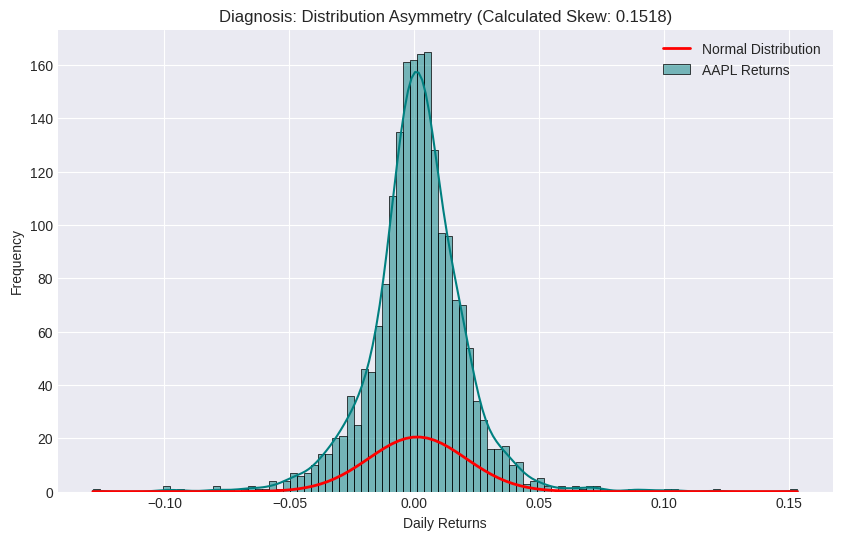

In [ ]:
# Challenge 2: Skewness Implementation
from scipy.stats import skew, norm

# Calculate numerical skewness
aapl_skew = skew(df['Returns'])

# Diagram: Distribution Plot
plt.figure(figsize=(10, 6))
sns.histplot(df['Returns'], kde=True, bins=100, color='teal', label='AAPL Returns')

# Overlay a normal distribution for comparison
x = np.linspace(df['Returns'].min(), df['Returns'].max(), 100)
plt.plot(x, norm.pdf(x, df['Returns'].mean(), df['Returns'].std()),
         color='red', lw=2, label='Normal Distribution')

plt.title(f"Diagnosis: Distribution Asymmetry (Calculated Skew: {aapl_skew:.4f})")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Challenge 3: Overfitting

### 1. Definition
Overfitting is a modeling error that occurs when a function is too closely aligned to a limited set of data points. Mathematically, it is characterized by a model that minimizes training error ($E_{in}$) but exhibits high generalization error ($E_{out}$):

$$E_{out} \gg E_{in}$$

### 2. Description
This problem arises when a model is overly complex and starts fitting random fluctuations in historical data instead of meaningful relationships. Consequently, while the model may perform extremely well on training data, it fails to deliver accurate predictions when applied to new or unseen data.

### 3. Diagnosis
Overfitting can be detected using out-of-sample testing or cross-validation techniques. A clear sign is when model performance is substantially better on the training dataset than on a validation dataset. Additionally, criteria such as the Akaike Information Criterion (AIC) help identify overfitting by penalizing excessive model complexity.

### 4. Damage
For a derivatives desk, an overfitted model is dangerous because it creates a false sense of security. A strategy may look highly profitable in a backtest, but once live capital is deployed, the model will fail to adapt to current market conditions. This leads to unexpected trading losses, "model risk," and potential catastrophic failure during market regime shifts.

### 5. Directions
To alleviate overfitting, quants should prioritize **Model Parsimony** (using the simplest model that explains the data). Technical solutions include using **Regularization (Lasso or Ridge regression)** to shrink unnecessary coefficients, or implementing **k-fold Cross-Validation** to ensure the model's stability across different time periods.

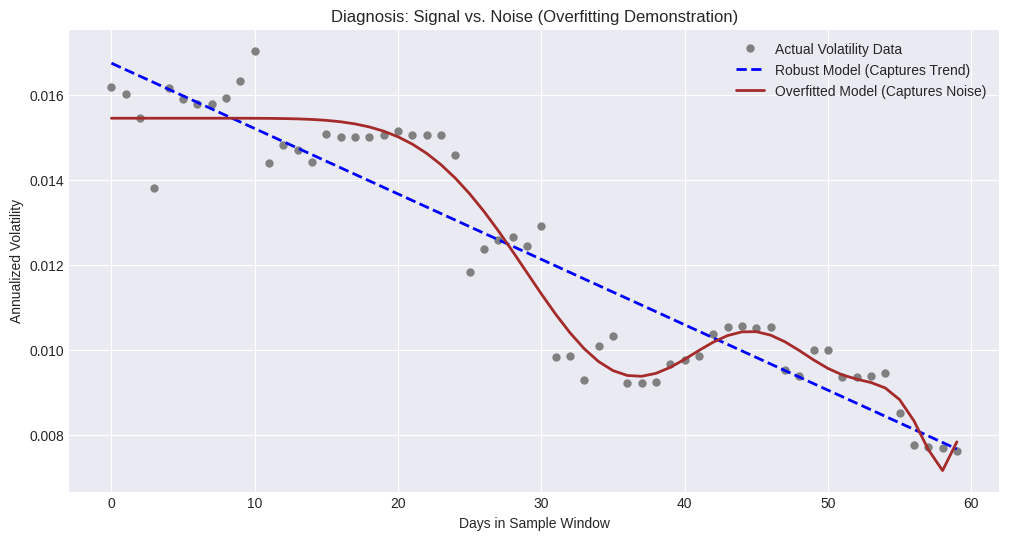

In [ ]:
# Challenge 3: Overfitting
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Select a recent 60-day sample for demonstration
sample = df.tail(60).copy()
x = np.arange(len(sample)).reshape(-1, 1)
y = sample['Volatility'].values

# Fit a simple linear model (Robust)
model_simple = LinearRegression().fit(x, y)

# Fit a 15th-degree polynomial (Overfit)
poly = PolynomialFeatures(degree=15)
x_poly = poly.fit_transform(x)
model_overfit = LinearRegression().fit(x_poly, y)

# Diagram: Signal vs. Noise
plt.figure(figsize=(12, 6))
plt.plot(x, y, 'o', label='Actual Volatility Data', color='gray', markersize=5)
plt.plot(x, model_simple.predict(x), color='blue', linestyle='--', linewidth=2, label='Robust Model (Captures Trend)')
plt.plot(x, model_overfit.predict(x_poly), color='brown', linewidth=2, label='Overfitted Model (Captures Noise)')

plt.title("Diagnosis: Signal vs. Noise (Overfitting Demonstration)")
plt.xlabel("Days in Sample Window")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.show()

## Challenge 4: Sensitivity to Outliers

### 1. Definition
An outlier is an observation that lies an abnormal distance from other values in a random sample from a population. In financial time series, outliers are often identified using the **Z-score**:

$$|Z| = \left|\frac{x - \mu}{\sigma}\right| > 3$$

### 2. Description
Outliers typically correspond to rare but impactful market events, such as financial crises, flash crashes, or unexpected geopolitical developments. Since many volatility models depend on squared returns, these extreme observations can disproportionately affect variance estimates and distort model outputs.

### 3. Diagnosis
The primary diagnostic tool is **Z-score thresholding**, where any data point exceeding three standard deviations from the mean is flagged. Visual diagnostics, such as **Box plots** or time-series residual plots, are also highly effective for recognizing these anomalies.

### 4. Damage
The presence of outliers can lead to what is often referred to as “ghost volatility,” where a single extreme event inflates volatility estimates for an extended period. This may result in overpriced derivatives and excessive margin requirements, ultimately reducing trading efficiency and profitability.

### 5. Directions
To alleviate this, quants should implement **Winsorization** (capping extreme values at a specific percentile, such as the 99th) or use **Robust Regression** techniques. These methods ensure that the model remains representative of the general market trend rather than being dictated by a single outlier.

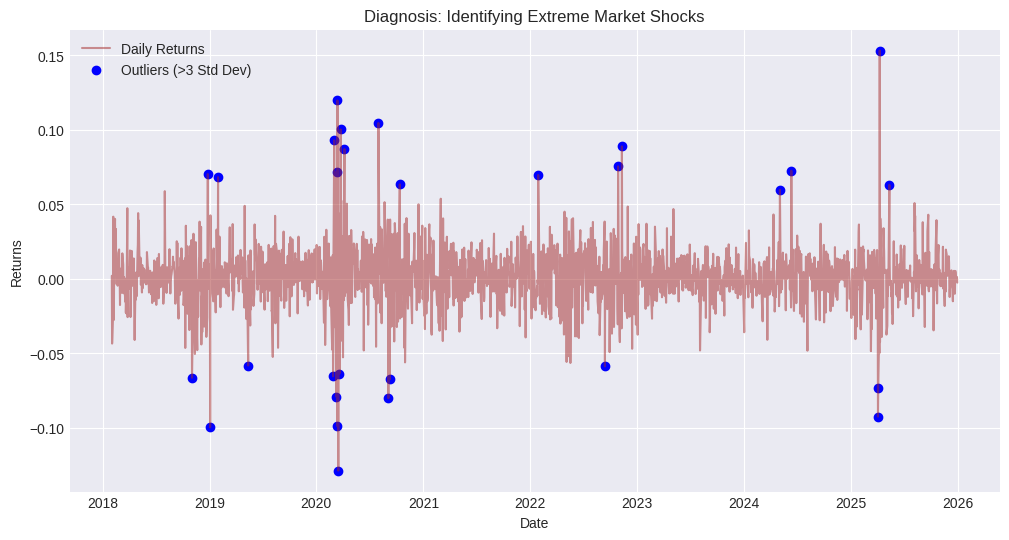

Number of outliers detected: 29


In [ ]:
# Challenge 4: Sensitivity to Outliers Implementation

# Calculate Z-scores for returns
df['Z_Score'] = (df['Returns'] - df['Returns'].mean()) / df['Returns'].std()

# Identify outliers
outliers = df[np.abs(df['Z_Score']) > 3]

# Diagram: Time Series with Outliers
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Returns'], label='Daily Returns', alpha=0.5, color='brown')
plt.scatter(outliers.index, outliers['Returns'], color='blue', label='Outliers (>3 Std Dev)')

plt.title("Diagnosis: Identifying Extreme Market Shocks")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend()
plt.show()

print(f"Number of outliers detected: {len(outliers)}")

Bibliography (MLA Format)

->"Apple Inc. (AAPL) Historical Data." Yahoo Finance, Yahoo!, 1 Jan. 2018 - 31 Dec. 2025, finance.yahoo.com/quote/AAPL/history/. Accessed 8 May 2026.

->Carriero, Andrea, et al. "Addressing COVID-19 Outliers in BVARs with Stochastic Volatility." Federal Reserve Bank of Cleveland, no. 22-09, 2022, pp. 1-35.

->López de Prado, Marcos. "Purged Cross-Validation." Wikipedia, Wikimedia Foundation, 14 Apr. 2025, en.wikipedia.org/wiki/Purged_cross-validation.

->Nugroho, Didit Budi, et al. "Skew Normal and Skew Student-T Distributions on GARCH(1,1) Model." Media Statistika, vol. 14, no. 1, 2021, pp. 21-32. DOI: 10.14710/medstat.14.1.21-32.

->"Ordinary Least Squares and Ridge Regression Variance." Scikit-learn, scikit-learn.org/stable/auto_examples/linear_model/plot_ols_ridge_variance.html. Accessed 8 May 2026.

->P. "The GT-Score: A Robust Objective Function for Reducing Overfitting in Data-Driven Trading Strategies." Journal of Risk and Financial Management, vol. 19, no. 1, 2026, p. 60. DOI: 10.3390/jrfm19010060